# PDelta3 Frontier Layer Lab

This notebook tests four focused recurrent-attention replacements against the frozen Transformer attention layer:

1. **`conv4_pdelta_f96`** — current Conv4 + PDelta2 F96 control.
2. **`conv4_channel_decay_f96`** — PDelta with stronger content-dependent per-feature KDA/GDN2-style decay.
3. **`conv4_gdn2_f96`** — GDN2-style independent key-channel erase and value-channel write gates, with short Conv4 on Q/K/V.
4. **`conv4_gdn2_clvr_f96`** — the GDN2 candidate plus one-hop **Cross-Layer Value Routing**: the previous layer's value representation is aligned and injected into the current write target.

The lab uses progressive **256 -> 512 -> 1024** adaptation, selects the architecture using a long-context validation score (512/1024/2048), and keeps the test set untouched until final evaluation at **512/1024/2048/4096**.

A strict Transformer quality win is reported only when the paired 95% bootstrap CI of `candidate NLL - Transformer NLL` is entirely below zero. The implementation is an independent TinyCeNN adaptation to frozen SmolLM2 Q/K/V, not a reproduction of full frontier-model pretraining or fused kernels.


In [1]:
import os, sys, subprocess, tempfile
from pathlib import Path

assert subprocess.run(["nvidia-smi"], check=False).returncode == 0, "Enable a GPU runtime in Colab."
REPO = Path(tempfile.mkdtemp(prefix="TinyCeNN-pdelta3-"))
subprocess.run(["git", "clone", "--depth", "1", "https://github.com/vtavakkoli/TinyCeNN-LM.git", str(REPO)], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers==4.57.6", "datasets", "huggingface_hub", "pandas", "matplotlib"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO), "--no-deps"], check=True)
print("Repository:", REPO)
subprocess.run(["git", "-C", str(REPO), "rev-parse", "HEAD"], check=True)


Repository: /tmp/TinyCeNN-pdelta3-8ttwwef5


CompletedProcess(args=['git', '-C', '/tmp/TinyCeNN-pdelta3-8ttwwef5', 'rev-parse', 'HEAD'], returncode=0)

In [2]:
from datetime import datetime, timezone

PROFILE = "balanced"          # quick | balanced | strong
LAYER = 18
CURRICULUM = "256,512,1024"
VALIDATION_CONTEXTS = "512,1024,2048"
TEST_CONTEXTS = "512,1024,2048,4096"
SEED = 2026

RESULT_ROOT = Path("/content/TinyCeNN-pdelta3-results")
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT_DIR = RESULT_ROOT / f"{PROFILE}-{stamp}"
print("Output:", OUTPUT_DIR)


Output: /content/TinyCeNN-pdelta3-results/balanced-20260914T224145221106Z


In [3]:
cmd = [
    sys.executable, str(REPO / "scripts" / "benchmark_pdelta3_frontier_layer.py"),
    "--profile", PROFILE,
    "--layer", str(LAYER),
    "--curriculum-contexts", CURRICULUM,
    "--validation-contexts", VALIDATION_CONTEXTS,
    "--test-contexts", TEST_CONTEXTS,
    "--seed", str(SEED),
    "--output-dir", str(OUTPUT_DIR),
]
print(" ".join(cmd), flush=True)
process = subprocess.Popen(cmd, cwd=REPO, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end="")
return_code = process.wait()
if return_code:
    raise subprocess.CalledProcessError(return_code, cmd)


/usr/bin/python3 /tmp/TinyCeNN-pdelta3-8ttwwef5/scripts/benchmark_pdelta3_frontier_layer.py --profile balanced --layer 18 --curriculum-contexts 256,512,1024 --validation-contexts 512,1024,2048 --test-contexts 512,1024,2048,4096 --seed 2026 --output-dir /content/TinyCeNN-pdelta3-results/balanced-20260914T224145221106Z
`torch_dtype` is deprecated! Use `dtype` instead!
2026-09-14 22:42:03.896444: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
data: train complete (48 documents)
data: validation complete (16 documents)
data: test complete (32 documents)
captured 8/48 at context 1024
captured 16/48 at context 1024
captured 24/48 at context 1024
captured 32/48 at context 1024
captured 40/48 at context 1024
captured 48/48 at context 1024
captured 8/16 

In [4]:
import json
import pandas as pd
from IPython.display import display

selection = json.loads((OUTPUT_DIR / "selection.json").read_text())
report = json.loads((OUTPUT_DIR / "pdelta3_frontier_report.json").read_text())
validation = pd.read_csv(OUTPUT_DIR / "validation_context_summary.csv")
test = pd.read_csv(OUTPUT_DIR / "test_summary.csv")
diagnostics = pd.read_csv(OUTPUT_DIR / "candidate_diagnostics.csv")
history = pd.read_csv(OUTPUT_DIR / "training_history.csv")

print("SELECTION")
print(json.dumps(selection, indent=2))
print("\nCANDIDATE DIAGNOSTICS")
display(diagnostics.sort_values("output_nmse"))
print("\nLONG-CONTEXT VALIDATION (used for selection)")
display(validation.sort_values(["context", "delta_nll"]))
print("\nHELD-OUT TEST")
display(test.sort_values(["context", "delta_nll"]))

strict = test[test["verdict"] == "strict_quality_win"]
print("\nANY STRICT TRANSFORMER QUALITY WIN:", "YES" if len(strict) else "NO")
if len(strict):
    display(strict)


SELECTION
{
  "quality_winner": "conv4_gdn2_clvr_f96",
  "efficient_winner": "conv4_pdelta_f96",
  "quality_criterion": "0.40*deltaNLL@512 + 0.35*@1024 + 0.25*@2048 on validation only",
  "validation_composite_delta_nll": {
    "conv4_pdelta_f96": 0.023167863488197327,
    "conv4_channel_decay_f96": 0.023161207884550096,
    "conv4_gdn2_f96": 0.022870177030563356,
    "conv4_gdn2_clvr_f96": 0.0223470076918602
  },
  "test_not_used_for_selection": true,
  "curriculum_contexts": [
    256,
    512,
    1024
  ],
  "validation_contexts": [
    512,
    1024,
    2048
  ]
}

CANDIDATE DIAGNOSTICS


,name,ingredient,output_nmse,output_cosine,prefill_ms,transformer_prefill_ms,prefill_speedup,decode_step_ms,transformer_decode_step_ms,decode_speedup,...,transformer_peak_extra_bytes,trainable_parameters,state_bytes,state_vs_transformer_fp16_1024,decay_half_life_min,decay_half_life_median,decay_half_life_max,erase_bias_mean,write_bias_mean,route_bias_mean
3,conv4_gdn2_clvr_f96,gdn2_plus_previous_layer_value_routing,0.396220,0.734147,27.578425,0.603752,0.021892,3.055688,0.285518,0.093438,...,7077888,152553,42624,0.054199,11.398998,87.841866,582.021484,0.268611,0.257959,0.018757
2,conv4_gdn2_f96,independent_channel_erase_write,0.397712,0.731853,33.688759,0.632989,0.018789,3.490475,0.367770,0.105364,...,7077888,127785,42624,0.054199,11.410654,87.702797,582.906799,0.268691,0.257992,NaN
0,conv4_pdelta_f96,current_control,0.404083,0.714797,41.213477,0.537945,0.013053,2.556283,0.317459,0.124188,...,7077888,125007,39168,0.049805,NaN,NaN,NaN,NaN,NaN,NaN
1,conv4_channel_decay_f96,kda_style_channel_decay,0.404597,0.730468,57.816440,0.593024,0.010257,3.832216,0.291042,0.075946,...,7077888,144015,39168,0.049805,11.155418,91.166580,611.980103,NaN,NaN,NaN



LONG-CONTEXT VALIDATION (used for selection)


,candidate,context,candidate_nll,transformer_nll,candidate_ppl,transformer_ppl,delta_nll,ci95_low,ci95_high,ppl_ratio,state_bytes,transformer_kv_bytes_fp16,state_vs_transformer_fp16,verdict,documents
9,conv4_gdn2_clvr_f96,512,2.553277,2.534727,12.849139,12.612986,0.018550,NaN,NaN,1.018723,42624,393216,0.108398,NaN,16
6,conv4_gdn2_f96,512,2.554204,2.534727,12.861052,12.612986,0.019477,NaN,NaN,1.019668,42624,393216,0.108398,NaN,16
0,conv4_pdelta_f96,512,2.554405,2.534727,12.863640,12.612986,0.019678,NaN,NaN,1.019873,39168,393216,0.099609,NaN,16
3,conv4_channel_decay_f96,512,2.554539,2.534727,12.865367,12.612986,0.019812,NaN,NaN,1.020010,39168,393216,0.099609,NaN,16
10,conv4_gdn2_clvr_f96,1024,2.575618,2.553209,13.139430,12.848264,0.022409,NaN,NaN,1.022662,42624,786432,0.054199,NaN,16
7,conv4_gdn2_f96,1024,2.576077,2.553209,13.145472,12.848264,0.022869,NaN,NaN,1.023132,42624,786432,0.054199,NaN,16
1,conv4_pdelta_f96,1024,2.576179,2.553209,13.146811,12.848264,0.022970,NaN,NaN,1.023236,39168,786432,0.049805,NaN,16
4,conv4_channel_decay_f96,1024,2.576321,2.553209,13.148671,12.848264,0.023112,NaN,NaN,1.023381,39168,786432,0.049805,NaN,16
8,conv4_gdn2_f96,2048,2.623368,2.595066,13.782061,13.397470,0.028302,NaN,NaN,1.028706,42624,1572864,0.027100,NaN,16
11,conv4_gdn2_clvr_f96,2048,2.623402,2.595066,13.782527,13.397470,0.028336,NaN,NaN,1.028741,42624,1572864,0.027100,NaN,16



HELD-OUT TEST


,candidate,context,selected_quality,selected_efficiency,candidate_nll,transformer_nll,candidate_ppl,transformer_ppl,delta_nll,ci95_low,ci95_high,ppl_ratio,state_bytes,transformer_kv_bytes_fp16,state_vs_transformer_fp16,verdict,documents
3,conv4_gdn2_clvr_f96,512,True,False,2.680036,2.664303,14.585615,14.357939,0.015733,0.010664,0.021437,1.015857,42624,393216,0.108398,inconclusive,32
2,conv4_gdn2_f96,512,False,False,2.680173,2.664303,14.587622,14.357939,0.015870,0.010684,0.021632,1.015997,42624,393216,0.108398,inconclusive,32
0,conv4_pdelta_f96,512,False,True,2.680187,2.664303,14.587814,14.357939,0.015883,0.010855,0.021642,1.016010,39168,393216,0.099609,inconclusive,32
1,conv4_channel_decay_f96,512,False,False,2.680519,2.664303,14.592672,14.357939,0.016216,0.011228,0.022282,1.016349,39168,393216,0.099609,inconclusive,32
7,conv4_gdn2_clvr_f96,1024,True,False,2.626936,2.605636,13.831327,13.539832,0.021300,0.015494,0.027653,1.021529,42624,786432,0.054199,inconclusive,32
6,conv4_gdn2_f96,1024,False,False,2.627275,2.605636,13.836019,13.539832,0.021639,0.016006,0.027918,1.021875,42624,786432,0.054199,inconclusive,32
5,conv4_channel_decay_f96,1024,False,False,2.627615,2.605636,13.840721,13.539832,0.021979,0.016441,0.028127,1.022223,39168,786432,0.049805,inconclusive,32
4,conv4_pdelta_f96,1024,False,True,2.627817,2.605636,13.843516,13.539832,0.022181,0.016557,0.028487,1.022429,39168,786432,0.049805,inconclusive,32
11,conv4_gdn2_clvr_f96,2048,True,False,2.638812,2.608616,13.996559,13.580244,0.030195,0.025246,0.035896,1.030656,42624,1572864,0.027100,worse_than_declared_margin,32
10,conv4_gdn2_f96,2048,False,False,2.639172,2.608616,14.001609,13.580244,0.030556,0.025491,0.036170,1.031028,42624,1572864,0.027100,worse_than_declared_margin,32



ANY STRICT TRANSFORMER QUALITY WIN: NO


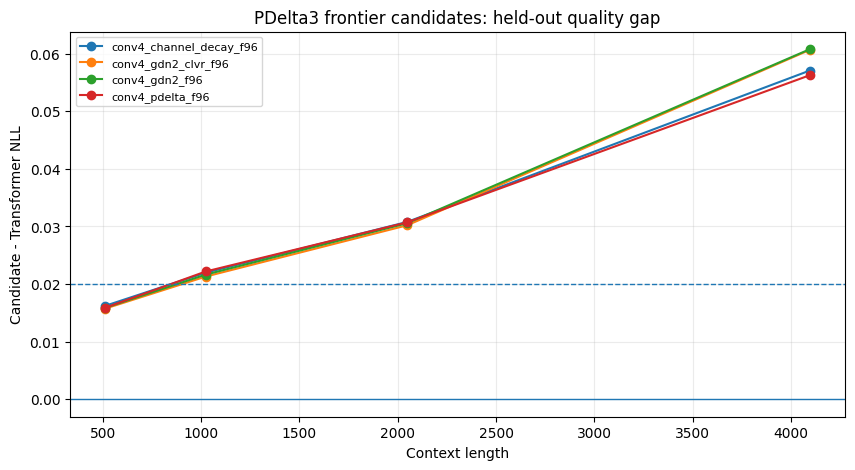

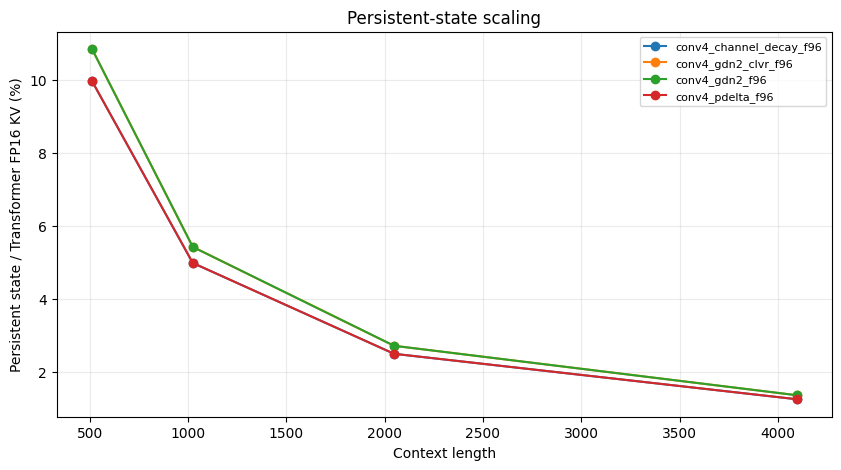

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for name, part in test.groupby("candidate"):
    part = part.sort_values("context")
    plt.plot(part["context"], part["delta_nll"], marker="o", label=name)
plt.axhline(0.0, linewidth=1)
plt.axhline(0.02, linewidth=1, linestyle="--")
plt.xlabel("Context length")
plt.ylabel("Candidate - Transformer NLL")
plt.title("PDelta3 frontier candidates: held-out quality gap")
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
for name, part in test.groupby("candidate"):
    part = part.sort_values("context")
    plt.plot(part["context"], 100 * part["state_vs_transformer_fp16"], marker="o", label=name)
plt.xlabel("Context length")
plt.ylabel("Persistent state / Transformer FP16 KV (%)")
plt.title("Persistent-state scaling")
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
plt.show()


In [6]:
import shutil
from google.colab import files

archive = shutil.make_archive(str(OUTPUT_DIR), "zip", root_dir=OUTPUT_DIR)
print("Downloading complete experiment:", archive)
files.download(archive)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>